# 10. Generative Adversarial Networks

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-06-09">09 Jun 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/10_gan.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
    The following sources were consulted in preparing this material:
    <ul style="margin-top: 0;">
      <li>
        Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., Courville, A., &amp; Bengio, Y. (2014).
        <a href="https://arxiv.org/abs/1406.2661">Generative Adversarial Networks</a>. NeurIPS 2014.
      </li>
      <li>
        Zhang, A., Lipton, Z. C., Li, M., &amp; Smola, A. J. (2023).
        <a href="https://d2l.ai/chapter_generative-adversarial-networks/index.html">Generative Adversarial Networks</a>. <i>Dive into Deep Learning</i>.
      </li>
      <li>
        Radford, A., Metz, L., &amp; Chintala, S. (2015).
        <a href="https://arxiv.org/abs/1511.06434">Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks</a>. arXiv:1511.06434.
      </li>
    </ul>
  </p>
</div>

[Generative Adversarial Networks](https://en.wikipedia.org/wiki/Generative_adversarial_network), commonly abbreviated as _GANs_ ([Goodfellow et al., 2014](https://arxiv.org/abs/1406.2661)), are generative models built from two [neural networks](../../notebooks/02_neural_network) with opposing objectives. One network, called the **generator**, receives random noise and transforms it into a synthetic data point. The other network, called the **discriminator**, receives a data point and estimates whether it came from the real dataset or from the generator. The generator improves by learning to produce samples that the discriminator classifies as real, while the discriminator improves by learning to separate real samples from generated samples.

<figure>
  <img src="../../assets/images/gan/gan.svg" alt="Generative adversarial network diagram" style="max-width: 80%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    <p>Generative Adversarial Networks ~ Zhang et al., <a href="https://d2l.ai/chapter_generative-adversarial-networks/gan.html">Dive into Deep Learning</a>, <a href='https://d2l.ai/_images/gan.svg'>Fig. 20.1.1</a>, <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.</p>
  </figcaption>
</figure>


In [supervised learning](../../introduction/02_machine_learning), an input image might come with a class label, and the loss tells the model exactly how wrong its prediction was. In a GAN, a noise vector has no predetermined correct image attached to it. The generator receives a training signal only through the discriminator, which means the quality of the generator's gradient depends on another model that is changing at the same time.

The main promise of GANs is that a neural network can learn to sample from a complicated data distribution without explicitly writing down the probability of each observation. For images, the real data distribution is the unknown distribution that produced the training images. For audio, it is the unknown distribution that produced the training waveforms, etc.

## Generative Modeling

Suppose observations are drawn from an unknown [probability distribution](../../mathematics/03_probability/#probability-distributions) $p^*(x)$. The symbol $p^*$ is used here for the true data-generating distribution, not because its formula is known, but because it is the ideal object being approximated. In practice, only a finite dataset $\{x^{(1)},x^{(2)},\ldots,x^{(n)}\}$ is observed. A generative model tries to learn a new distribution $p_\theta(x)$ whose samples resemble samples from $p^*(x)$.

Before using a neural network, it is useful to inspect the shape of the [latent](https://en.wikipedia.org/wiki/Latent_and_observable_variables) input. Each row below is one latent vector. In an image GAN, a latent vector might eventually determine high-level features such as pose, color, or texture, although those meanings are not assigned manually in a vanilla GAN.
A standard normal distribution is common because it is easy to sample, symmetric, and has independent coordinates. The generator's task is to bend, stretch, fold, and reshape this simple distribution into something that looks like the data distribution.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

LATENT_DIM = 6

z = torch.randn(4, LATENT_DIM) # random normal
z

tensor([[-0.8201,  0.3956,  0.8989, -1.3884, -0.1670,  0.2851],
        [-0.6411, -0.8937, -0.8489, -1.2169, -0.0810,  1.3615],
        [-1.3032,  0.0875, -1.3850,  0.5036, -0.8667, -0.5640],
        [-2.0565, -0.3567,  1.0956,  0.4824,  1.3989,  1.4059]])

GANs represent $p_\theta(x)$ implicitly. Instead of evaluating a probability density, they define a sampling procedure. First sample a [latent variable](../../notebooks/08_vae) vector $z$ from a simple distribution such as a standard Gaussian. Then pass that vector through a neural network $G_\theta$ to obtain a generated sample $\tilde{x}=G_\theta(z)$. The distribution of $\tilde{x}$ is the model distribution, even if its probability density at a particular point is not easy to compute.

A generator is a deterministic function once its input $z$ and parameters $\theta$ are fixed. Randomness enters because a different $z$ is sampled each time. This is similar to many other generative procedures: the model itself is fixed, but the random seed changes the outcome. If the generator is trained well, producing a new sample is only a forward pass through a neural network. The trade-off is that likelihood-based training becomes difficult, because there is no simple formula for $p_\theta(x)$ that can be maximized. GANs replace likelihood training with a learned comparison between real and generated samples.

In our simple implementation, the real data will be a one-dimensional [Gaussian mixture](../../mathematics/03_probability/#mixture-distributions) distribution with two separated bumps. This is much simpler than images, but it already contains one important challenge. A generator should learn both regions of high probability, not only one of them. When a generator repeatedly produces samples from only a small part of the real distribution, the failure is called **mode collapse**. The code below samples from an equal-weight mixture of Gaussian components. For `modes=2`, each observation is produced by first choosing one of two Gaussian components and then adding Gaussian noise around that component center.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    The word <em>mode</em> refers to a region where probability mass is concentrated. Handwritten digits have multiple modes because the dataset contains different digit classes and many writing styles. Face images have modes related to pose, lighting, identity, background, and expression. A two-bump distribution is therefore a deliberately tiny version of a much larger problem.
  </p>
</div>

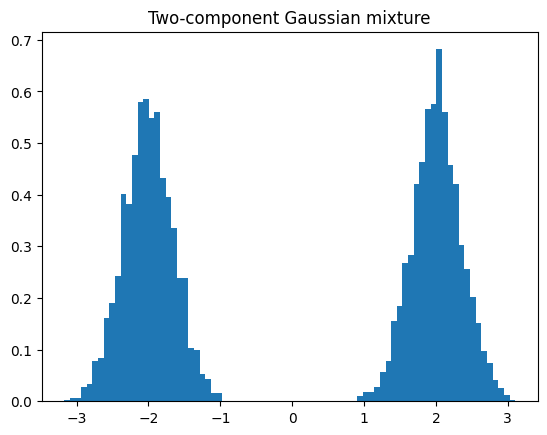

In [2]:
def sample_GM(batch_size, modes=2):
  centers = torch.linspace(-2.0, 2.0, modes)
  assignments = torch.randint(0, modes, (batch_size,))
  noise = 0.35 * torch.randn(batch_size, 1)
  return centers[assignments].view(-1, 1) + noise

real = sample_GM(4096, modes=2)

plt.hist(real.squeeze().numpy(), bins=80, density=True)
plt.title('Two-component Gaussian mixture');

The generator will not be given the formula used in `sample_GM`, even though the function is explicitly a small Gaussian mixture sampler. It will only see samples from this function during training. This mirrors the realistic setting in which a dataset is available but the distribution that produced it is unknown. This distribution is also useful because mistakes are visible. If generated samples cover both peaks with roughly the correct spread, the generator has learned a reasonable approximation. If samples collect around one peak, between the peaks, or far outside the real range, the problem is immediately clear from a histogram.

## Generator

The generator receives a latent vector and returns one generated number. Its output dimension is one only because the toy data are one-dimensional. For [image generation](../../notebooks/08_vae), the output might have shape $3\times64\times64$ or larger. The role is the same: transform a simple random input into a data-shaped object. The class below uses two hidden layers. There is no sigmoid or softmax at the output, because the generated value can be any real number. In image models, the last activation is often chosen to match the preprocessing range. For example, `tanh` is common when images are normalized to $[-1,1]$.

In [3]:
HIDDEN_DIM = 64

class Generator(nn.Module):
  def __init__(self, latent_dim=LATENT_DIM):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(latent_dim, HIDDEN_DIM),
      nn.ReLU(),
      nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
      nn.ReLU(),
      nn.Linear(HIDDEN_DIM, 1),
    )

  def forward(self, z):
    return self.net(z)

At initialization, the generator is simply a random function. It has the right input and output shapes, but its samples do not yet match the real distribution. This is worth checking because it gives a baseline for what training changes. The following helper samples latent vectors, passes them through the generator, and returns generated values on the CPU so that they can be plotted easily.


In [4]:
G = Generator().to(DEVICE)

@torch.no_grad()
def sample_fake(generator, n=4096):
  z = torch.randn(n, LATENT_DIM, device=DEVICE)
  return generator(z).cpu()

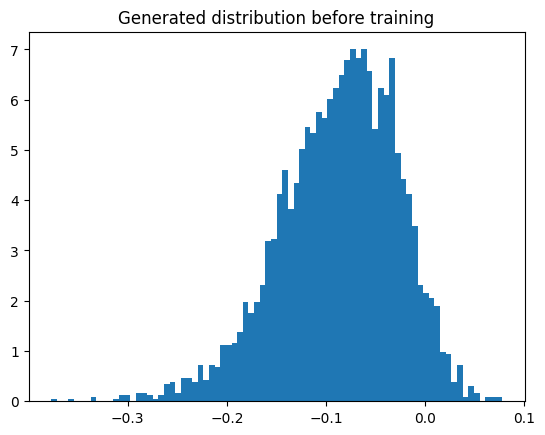

In [5]:
fake = sample_fake(G)

plt.hist(fake.squeeze().numpy(), bins=80, density=True)
plt.title('Generated distribution before training');

The generated distribution before training is not meaningful. It reflects the random initialization of the network, the latent distribution, and the final linear layer. The goal of training is to move this distribution until generated samples become difficult to distinguish from real samples. Notice that distributions are being compared, not paired examples. There is no real data point that corresponds to a particular latent vector. This is why a reconstruction loss such as $\|x-\hat{x}\|^2$ is not available in the vanilla GAN setting.

## Discriminator

The discriminator is a binary classifier. It receives one data point and returns one logit. Positive logits correspond to a high probability of being real after applying the sigmoid function, while negative logits correspond to a low probability of being real. It is better to return logits rather than probabilities because PyTorch's `BCEWithLogitsLoss` combines the sigmoid and binary cross-entropy in a numerically stable way. We have already seen the same pattern appearing in binary classification in our earlier notebooks. The model returns raw scores, and the loss function handles the conversion to probabilities internally.

In [6]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(1, HIDDEN_DIM),
      nn.LeakyReLU(0.2),
      nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
      nn.LeakyReLU(0.2),
      nn.Linear(HIDDEN_DIM, 1),
    )

  def forward(self, x):
    return self.net(x)

In [7]:
D = Discriminator().to(DEVICE)

x = sample_GM(4).to(DEVICE)
logits = D(x)
probs = torch.sigmoid(logits)

x.shape, logits.shape, probs.squeeze()

(torch.Size([4, 1]),
 torch.Size([4, 1]),
 tensor([0.4442, 0.4410, 0.4571, 0.4644], device='cuda:0',
        grad_fn=<SqueezeBackward0>))

The discriminator's output is not useful before training. It has not yet learned what real data look like. During training, real samples are labeled with target $1$, and generated samples are labeled with target $0$. This creates a supervised learning problem for the discriminator. The unusual part is that half of its training data come from the generator, and that generator changes after every update. The discriminator is therefore not learning against a fixed negative class. It is learning against an adaptive opponent.

## Binary Cross-Entropy for Real and Fake Samples

Recall from binary classification that, for a discriminator output probability $D(x)$, [binary cross-entropy](../../mathematics/05_prob_modeling/#binary-cross-entropy) with label $y\in\{0,1\}$ is

$$
\ell(D(x),y)
=
-y\log D(x) - (1-y)\log(1-D(x)).
$$

If $y=1$, the loss becomes $-\log D(x)$, so the discriminator is penalized when it assigns low real probability to a real sample. If $y=0$, the loss becomes $-\log(1-D(x))$, so the discriminator is penalized when it assigns high real probability to a fake sample. This is exactly the behavior needed for the discriminator. In the GAN setting, the same formula is applied twice in each discriminator update: once to real samples with label $1$, and once to generated samples with label $0$. The discriminator therefore learns a classifier whose decision boundary depends on both the current data distribution and the current generator distribution.

The PyTorch implementation below uses `BCEWithLogitsLoss`, so the discriminator should return logits rather than probabilities. If the discriminator already applied `sigmoid`, the loss would effectively receive probabilities while expecting logits, which changes the numerical behavior of the objective. Keeping logits in the model and letting the loss handle the sigmoid is the cleaner convention.

In [8]:
bce = nn.BCEWithLogitsLoss()

def discriminator_loss(real_logits, fake_logits):
  real_targets = torch.ones_like(real_logits)
  fake_targets = torch.zeros_like(fake_logits)
  real_loss = bce(real_logits, real_targets)
  fake_loss = bce(fake_logits, fake_targets)
  return real_loss + fake_loss

def generator_loss(fake_logits):
  real_targets = torch.ones_like(fake_logits)
  return bce(fake_logits, real_targets)

The generator wants fake samples to be classified as real, but this does not mean the fake samples are relabeled permanently in the dataset. The target $1$ is used only for the generator update, because the generator is rewarded when the discriminator gives high real probability to generated samples. A convenient generator loss is therefore binary cross-entropy with target $1$ for generated samples. This is called the **non-saturating** generator loss. The original minimax expression discussed in the next section can also be used to describe the generator's goal, but the non-saturating version often provides stronger gradients early in training. In the early phase, the discriminator may confidently reject generated samples. Directly minimizing the minimax generator loss can then give gradients that are too small, because $\log(1-D(G(z)))$ becomes relatively flat when $D(G(z))$ is already close to $0$. The non-saturating loss instead minimizes $-\log D(G(z))$, which strongly penalizes the generator when the discriminator confidently rejects fake samples. The equilibrium goal is the same, but the early training signal is usually more useful.

In [9]:
BATCH_SIZE = 16
real_x = sample_GM(BATCH_SIZE).to(DEVICE)
z = torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE)
fake_x = G(z)

real_logits = D(real_x)
fake_logits = D(fake_x)

discriminator_loss(real_logits, fake_logits), generator_loss(fake_logits)

(tensor(1.4785, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(0.6974, device='cuda:0',
        grad_fn=<BinaryCrossEntropyWithLogitsBackward0>))

The two losses are computed from many of the same objects, but their parameter updates should affect different networks. When the discriminator is being trained, generated samples should be treated as fixed examples from the current generator. The discriminator update should not change the generator. In PyTorch, this is handled with `.detach()`. Detaching is a small code detail but it has major importance. Without it, gradients from the discriminator loss would flow into the generator during the discriminator update. Then the generator would be affected by a loss whose purpose is to make the discriminator better, not to make generated samples better.

In [11]:
fake_logits_for_d = D(fake_x.detach())
d_loss = discriminator_loss(real_logits, fake_logits_for_d)

d_loss.item()

1.4785127639770508

## Minimax Objective

The original GAN objective may seem complicated at first glance:

$$
\min_G \max_D V(D,G)
=
\mathbb{E}_{x\sim p^*(x)}[\log D(x)]
+
\mathbb{E}_{z\sim p(z)}[\log(1-D(G(z)))].
$$

The discriminator tries to maximize this expression. It wants $D(x)$ to be large for real samples and $D(G(z))$ to be small for generated samples. The generator tries to minimize the same expression by making $D(G(z))$ large. Because one side maximizes and the other side minimizes, the objective is called a [minimax](https://en.wikipedia.org/wiki/Minimax) game (which should be familiar if you have taken an introductory AI course). Here, minimax is a precise optimization structure in which two parameterized functions have opposing goals. The discriminator estimates a boundary between real and generated samples. The generator changes the generated distribution so that this boundary becomes less useful.

For a fixed generator, the optimal discriminator has a simple mathematical form. The reason is that, at each possible value of $x$, the discriminator is choosing a number $D(x)\in(0,1)$ to maximize a weighted sum of two terms: $p^*(x)\log D(x)$ for real data and $p_\theta(x)\log(1-D(x))$ for generated data. Taking the derivative of that expression with respect to $D(x)$ and setting it to zero gives

$$
\frac{p^*(x)}{D(x)} - \frac{p_\theta(x)}{1-D(x)} = 0,
\qquad
D^*(x)=\frac{p^*(x)}{p^*(x)+p_\theta(x)}.
$$

This formula gives intuition for what the discriminator is trying to estimate. If a point is much more likely under the real data distribution than under the generator distribution, the numerator dominates and $D^*(x)$ is close to $1$. If a point is much more likely under the generator distribution, $D^*(x)$ is close to $0$. If the real and generated distributions match exactly, then $D^*(x)=1/2$ everywhere, so the discriminator cannot do better than random guessing.

Under idealized assumptions, the minimax objective corresponds to minimizing a [divergence](../../mathematics/04_information/#kullback-leibler-divergence) between the real distribution and the generator distribution. The practical training procedure is much less idealized. The networks have finite capacity, optimization is approximate, and the two models change in alternating steps rather than reaching an exact optimum after each update.

## Training GANs with Alternating Optimization

GAN training alternates between discriminator updates and generator updates. In the discriminator step, real samples are labeled real and generated samples are labeled fake. In the generator step, new generated samples are passed through the discriminator, but the loss asks the discriminator to call them real. The following code uses [AdamW](../../notebooks/04_regul_optim/#adam) with `betas=(0.5, 0.999)`, a setting that became common in early GAN implementations. In the training loop, the discriminator sees detached fake samples. The generator receives gradients through the discriminator, but only the generator optimizer is stepped during the generator update.

In [12]:
from torch.optim import AdamW

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_g = AdamW(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = AdamW(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [13]:
BATCH_SIZE = 256
STEPS = 3000

history = {'d_loss': [], 'g_loss': []}

In [14]:
for step in range(STEPS):
  real_x = sample_GM(BATCH_SIZE).to(DEVICE)
  z = torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE)
  fake_x = G(z)

  real_logits = D(real_x)
  fake_logits = D(fake_x.detach())
  d_loss = discriminator_loss(real_logits, fake_logits)

  opt_d.zero_grad()
  d_loss.backward()
  opt_d.step()

  z = torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE)
  fake_x = G(z)
  fake_logits = D(fake_x)
  g_loss = generator_loss(fake_logits)

  opt_g.zero_grad()
  g_loss.backward()
  opt_g.step()

  history['d_loss'].append(d_loss.item())
  history['g_loss'].append(g_loss.item())

  if (step + 1) % 500 == 0:
    print(f'step={step+1:04d} d_loss={d_loss.item():.3f} g_loss={g_loss.item():.3f}')

step=0500 d_loss=1.254 g_loss=0.820
step=1000 d_loss=1.264 g_loss=0.826
step=1500 d_loss=1.346 g_loss=0.737
step=2000 d_loss=1.344 g_loss=0.713
step=2500 d_loss=1.367 g_loss=0.741
step=3000 d_loss=1.377 g_loss=0.715


The loss curves of a GAN should be interpreted carefully. In a normal supervised classifier, a steadily decreasing training loss is usually a sign that the model is fitting the training objective. In a GAN, the generator and discriminator losses are coupled. If the discriminator improves, the generator loss may rise. If the generator improves, the discriminator loss may rise because fake samples become harder to classify. For that reason, GAN losses often look noisier than ordinary supervised losses. A stable-looking curve does not guarantee good samples, and a noisy curve does not necessarily mean failure. Visual inspection, distributional plots, and domain-specific metrics are usually more informative than the loss values alone.

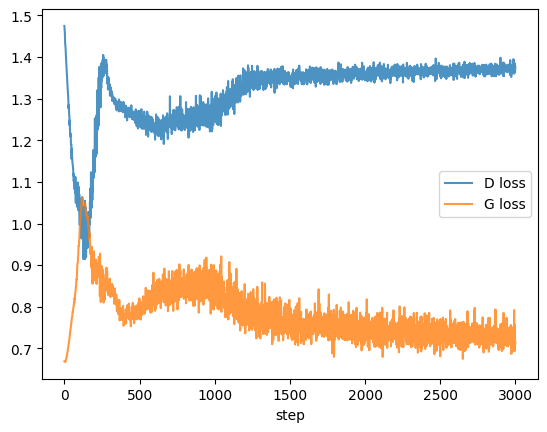

In [15]:
plt.plot(history['d_loss'], label='D loss', alpha=0.8)
plt.plot(history['g_loss'], label='G loss', alpha=0.8)
plt.xlabel('step')
plt.legend();

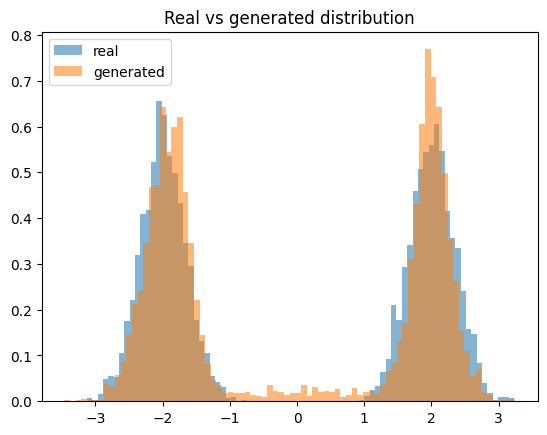

In [16]:
@torch.no_grad()
def compare_distributions(generator, n=4096):
  real = sample_GM(n).squeeze().numpy()
  fake = sample_fake(generator, n).squeeze().numpy()

  plt.hist(real, bins=80, density=True, alpha=0.55, label='real')
  plt.hist(fake, bins=80, density=True, alpha=0.55, label='generated')
  plt.legend()
  plt.title('Real vs generated distribution');

compare_distributions(G)

The generated distribution should now be much closer to the real distribution than it was at initialization. Because this is a small adversarial training problem, results may vary across runs. Sometimes both modes are covered well. Sometimes one mode is underrepresented. This variation is a small example of the instability that made GAN training a serious research topic and later motivated comparisons with other generative families such as [diffusion models](../../notebooks/09_diffusion). A useful way to think about the training result is to separate sample quality from sample diversity. If generated values lie near real-looking regions, quality is reasonable. If generated values cover all important regions of the real distribution, diversity is reasonable. GANs can produce high-quality samples while still losing diversity, which is why mode collapse can be visually subtle in complex datasets.

## Discriminator after Training

The discriminator learns a function over the data space. In one dimension, this function can be plotted directly. Regions that the discriminator believes are real should have high sigmoid probability, while regions that it believes are fake should have low probability. The plot below is not meant to be a perfect density estimator. The discriminator is trained only to separate current generated samples from real samples. Its shape depends on the generator and on the recent training trajectory. Still, it helps make the feedback signal concrete.

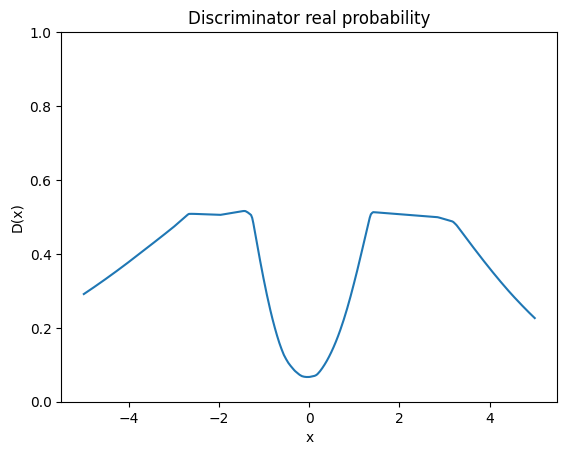

In [17]:
@torch.no_grad()
def plot_discriminator(discriminator):
  grid = torch.linspace(-5, 5, 400).view(-1, 1).to(DEVICE)
  probs = torch.sigmoid(discriminator(grid)).cpu().squeeze()

  plt.plot(grid.cpu().squeeze(), probs)
  plt.ylim(0, 1)
  plt.xlabel('x')
  plt.ylabel('D(x)')
  plt.title('Discriminator real probability');

plot_discriminator(D)

If the generator distribution closely matches the real distribution, an ideal discriminator would output approximately $0.5$ where samples occur. If the generator misses a region, the discriminator can assign high real probability there because real samples appear but fake samples do not. If the generator places mass in unrealistic regions, the discriminator can assign low real probability there. In higher-dimensional settings, the discriminator's behavior is harder to visualize. The same idea remains: it provides gradients pointing generated samples toward regions that look more like the training data.

## Latent Space Interpolation

A trained generator maps nearby latent vectors to generated samples. If the learned mapping is smooth, interpolation in latent space can produce meaningful transitions. In image GANs, this is often shown by interpolating between two latent vectors and observing a gradual change in the generated image (you might have seen a video or two with smooth celebrity age transitions). For the one-dimensional example, interpolation is less visually impressive, but it still shows that the generator is a continuous function of $z$. Two latent vectors are chosen, a line is drawn between them, and each point on that line is passed through the generator.

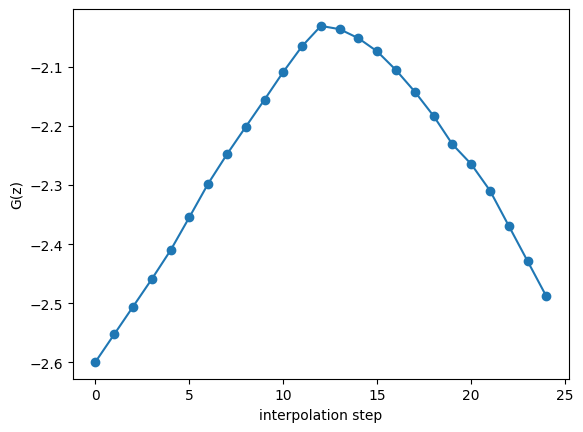

In [18]:
@torch.no_grad()
def interpolate(generator, steps=25):
  z0 = torch.randn(1, LATENT_DIM, device=DEVICE)
  z1 = torch.randn(1, LATENT_DIM, device=DEVICE)
  alphas = torch.linspace(0, 1, steps, device=DEVICE).view(-1, 1)
  z = (1 - alphas) * z0 + alphas * z1
  return generator(z).cpu().squeeze()

values = interpolate(G)
plt.plot(values, marker='o')
plt.xlabel('interpolation step')
plt.ylabel('G(z)');

The plotted path may pass through one mode, the other mode, or the space between them depending on the chosen endpoints. In image generation, interpolation is often used as a qualitative test of whether the latent space has learned a useful organization. A good latent space should not behave like a table of unrelated memorized examples. However, smooth interpolation alone does not prove that the model learned the full data distribution. A generator can interpolate smoothly while still missing modes. As usual, one diagnostic gives only one view of the model.

## Generating Images with GANs

The same adversarial objective can be used for images by changing the generator and discriminator architectures. The generator maps a latent vector into an image tensor. The discriminator maps an image tensor into a single real/fake logit. The loss functions and alternating optimization remain almost unchanged. For image data, [convolutional](../../notebooks/03_cnn_torch/#convolutional-neural-network) structure is important. Neighboring pixels are related, and patterns such as edges, textures, and object parts are spatially local. Fully connected layers ignore this structure and become expensive for large images. Convolutional generators and discriminators therefore became the standard choice for early image GANs.

**DCGAN**, or Deep Convolutional GAN ([Radford et al., 2015](https://arxiv.org/abs/1511.06434)), was one of the first widely influential demonstrations that GANs could learn useful image representations with a relatively simple convolutional design. The paper recommended replacing pooling with strided convolutions, using transposed convolutions for upsampling in the generator, using [batch normalization](../../notebooks/05_cnn_architectures/#batch-normalization) in most layers, using ReLU in the generator, and using LeakyReLU in the discriminator. The next code defines a small DCGAN-style generator for $64\times64$ RGB images. The architecture starts from a latent tensor of shape `(batch, latent_dim, 1, 1)` and repeatedly upsamples until the spatial size reaches $64\times64$. The final `tanh` activation matches the common preprocessing convention in which images are normalized to the range $[-1,1]$.

In [19]:
class DCGANGenerator(nn.Module):
  def __init__(self, latent_dim=100, base_channels=64, out_channels=3):
    super().__init__()
    self.net = nn.Sequential(
      nn.ConvTranspose2d(latent_dim, base_channels * 8, 4, 1, 0, bias=False),
      nn.BatchNorm2d(base_channels * 8),
      nn.ReLU(True),
      nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 4, 2, 1, bias=False),
      nn.BatchNorm2d(base_channels * 4),
      nn.ReLU(True),
      nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1, bias=False),
      nn.BatchNorm2d(base_channels * 2),
      nn.ReLU(True),
      nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1, bias=False),
      nn.BatchNorm2d(base_channels),
      nn.ReLU(True),
      nn.ConvTranspose2d(base_channels, out_channels, 4, 2, 1, bias=False),
      nn.Tanh(),
    )

  def forward(self, z):
    return self.net(z)

The discriminator moves in the opposite direction. It receives an image and gradually reduces spatial resolution while increasing the number of channels. At the end, it produces one logit per image. The discriminator below uses [LeakyReLU](../../mathematics/03_probability/#relu) activations. A standard ReLU would set all negative activations to zero. LeakyReLU keeps a small slope for negative values, which often helps discriminator gradients flow more reliably during GAN training.

In [20]:
class DCGANDiscriminator(nn.Module):
  def __init__(self, in_channels=3, base_channels=64):
    super().__init__()
    self.net = nn.Sequential(
      nn.Conv2d(in_channels, base_channels, 4, 2, 1, bias=False),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1, bias=False),
      nn.BatchNorm2d(base_channels * 2),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1, bias=False),
      nn.BatchNorm2d(base_channels * 4),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Conv2d(base_channels * 4, base_channels * 8, 4, 2, 1, bias=False),
      nn.BatchNorm2d(base_channels * 8),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Conv2d(base_channels * 8, 1, 4, 1, 0, bias=False),
    )

  def forward(self, x):
    return self.net(x).view(x.size(0), 1)

In [21]:
LATENT_DIM = 100
image_G = DCGANGenerator(latent_dim=LATENT_DIM).to(DEVICE)
image_D = DCGANDiscriminator().to(DEVICE)

z = torch.randn(8, LATENT_DIM, 1, 1, device=DEVICE)
fake_images = image_G(z)
image_logits = image_D(fake_images)

fake_images.shape, image_logits.shape

(torch.Size([8, 3, 64, 64]), torch.Size([8, 1]))

The output shape `(8, 3, 64, 64)` means that the generator produced eight RGB images. The discriminator returned shape `(8, 1)`, one logit for each image. These shape checks are simple, but they prevent many mistakes when moving from scalar data to images. Because the image generator above is untrained, its outputs are random texture-like patterns. That is expected. A real image GAN training loop would use the same discriminator and generator losses as before, but the real samples would come from an image dataset and training would require more compute.

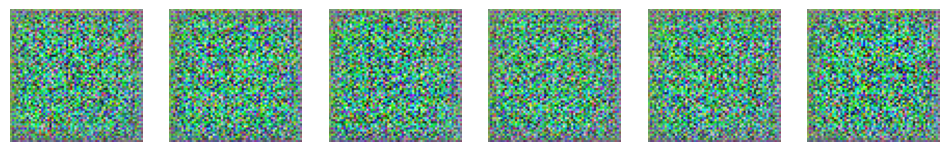

In [22]:
def show_images(xs, n=6):
  xs = xs[:n].detach().cpu()
  xs = ((xs + 1) / 2).clamp(0, 1)

  fig, ax = plt.subplots(1, n, figsize=(2*n, 2))
  for i in range(n):
    ax[i].imshow(xs[i].permute(1, 2, 0))
    ax[i].axis('off')
  plt.show()

show_images(fake_images)

## Conditional GANs

A vanilla generator receives only noise, so the user cannot directly request a particular kind of sample. A **conditional GAN** ([Mirza and Osindero, 2014](https://arxiv.org/pdf/1411.1784)) adds side information $y$ to both the generator and the discriminator. The generator becomes $G(z,y)$, and the discriminator judges whether a pair $(x,y)$ is realistic. The condition might be a class label, a text embedding, a segmentation mask, an edge image, or another image. For a digit dataset, $y$ could specify which digit should be generated. For image-to-image translation, $y$ could be an input sketch and $x$ could be the corresponding generated photograph. Conditioning turns a GAN from an uncontrolled sampler into a controllable generator.

In [23]:
class ConditionalGenerator(nn.Module):
  def __init__(self, latent_dim=8, num_classes=10, hidden_dim=64):
    super().__init__()
    self.embed = nn.Embedding(num_classes, num_classes)
    self.fc1 = nn.Linear(latent_dim + num_classes, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, 1)

  def forward(self, z, y):
    y_emb = self.embed(y)
    h = torch.cat([z, y_emb], dim=1)
    return self.fc2(F.relu(self.fc1(h)))

In [24]:
z = torch.randn(4, 8)
y = torch.tensor([0, 1, 2, 3])

ConditionalGenerator()(z, y).shape

torch.Size([4, 1])

The example concatenates a learned class embedding with the latent vector. For images, conditioning can be introduced in more powerful ways, such as [conditional batch normalization](../../notebooks/05_cnn_architectures/#batch-normalization) or [cross-attention](../../notebooks/07_transformer/#attention). The small example is only meant to show the first principle: the generator receives both randomness and a condition. The discriminator should also be conditioned. If the generator is asked to produce class $3$, an image of class $8$ should not be considered successful merely because it looks realistic. The discriminator must judge compatibility between the generated sample and the condition.

## Wasserstein GANs

One reason vanilla GANs can be unstable is that the discriminator may become too good, causing weak gradients for the generator. Wasserstein GANs ([Arjovsky et al., 2017](https://arxiv.org/abs/1701.07875)) modify the objective to provide a more useful training signal. Instead of a discriminator that outputs a probability, WGAN uses a **critic** that outputs an unrestricted real-valued score. The WGAN objective is motivated by the [Earth-Mover (Wasserstein-1) distance](https://en.wikipedia.org/wiki/Wasserstein_metric) between distributions. Informally, this distance measures how much work is needed to move probability mass from one distribution to another. The practical benefit is that the critic can provide meaningful gradients even when the real and generated distributions have little overlap.

A simple way to imagine Earth-Mover distance is to place two piles of soil on a line. One pile represents the real distribution and the other represents the generated distribution. The distance measures the minimum amount of work needed to move soil from the generated pile until it matches the real pile, where work is mass times distance. If probability mass is only slightly misplaced, the distance is small. If mass must move far, the distance is large. This is different from classification-based separation, where two distributions with little overlap can become too easy to distinguish and leave the generator with a poor signal.


In [25]:
def critic_loss(real_scores, fake_scores):
  return fake_scores.mean() - real_scores.mean()

def wgan_generator_loss(fake_scores):
  return -fake_scores.mean()

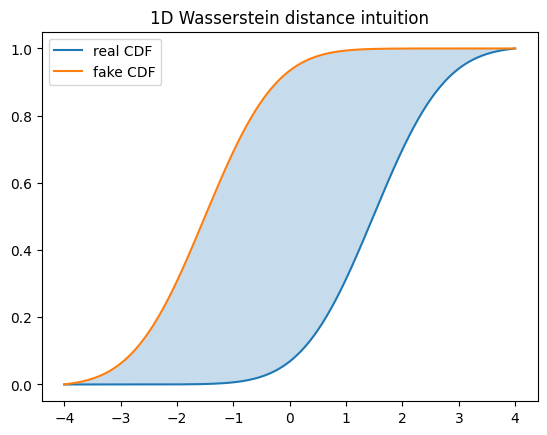

In [26]:
import torch
import matplotlib.pyplot as plt

xs = torch.linspace(-4, 4, 400)
real_density = torch.exp(-0.5 * (xs - 1.5)**2)
fake_density = torch.exp(-0.5 * (xs + 1.5)**2)

real_density = real_density / real_density.sum()
fake_density = fake_density / fake_density.sum()

real_cdf = torch.cumsum(real_density, dim=0)
fake_cdf = torch.cumsum(fake_density, dim=0)

plt.plot(xs, real_cdf, label='real CDF')
plt.plot(xs, fake_cdf, label='fake CDF')
plt.fill_between(xs, real_cdf, fake_cdf, alpha=0.25)
plt.title('1D Wasserstein distance intuition')
plt.legend();

The signs are different from binary cross-entropy. The critic is trained to assign higher scores to real samples than fake samples, so its loss minimizes `fake_scores.mean() - real_scores.mean()`. The generator is trained to make fake samples receive high critic scores, so it minimizes the negative mean fake score. WGAN also needs a constraint: the critic must be [Lipschitz continuous](https://en.wikipedia.org/wiki/Lipschitz_continuity), meaning that its output cannot change arbitrarily fast when the input changes. The original WGAN paper enforced this by clipping critic weights.

## Discriminator as a Learned Comparison

It is tempting to think of the discriminator as a separate classifier that is useful only during training. That is partly true, but it misses the reason the discriminator gives the generator a meaningful signal. The discriminator is trained on samples from two distributions: real samples from $p^*(x)$ and generated samples from $p_\theta(x)$. A classifier trained to separate these two sources must learn where the two distributions differ.

This view is especially important because the generator does not compare its output to a fixed target. A generated point $\tilde{x}=G(z)$ is not told to move toward a particular real point $x^{(i)}$. Instead, the discriminator tells it whether the region it occupies looks more real or more fake. The generator then changes its parameters so that future generated samples move toward regions that the discriminator scores as real. The optimal discriminator formula can be read as a [density-ratio](../../mathematics/05_prob_modeling) statement. Since

$$
D^*(x)=\frac{p^*(x)}{p^*(x)+p_\theta(x)},
$$

the discriminator is large where real density dominates generated density and small where generated density dominates real density. Hence the discriminator can be useful even though it is trained with only binary labels. It is not merely memorizing labels. In the idealized case, it estimates how two distributions compare at each point.

In [27]:
@torch.no_grad()
def discriminator_table(discriminator, xs=(-3, -2, 0, 2, 3)):
  x = torch.tensor(xs, dtype=torch.float32, device=DEVICE).view(-1, 1)
  logits = discriminator(x)
  probs = torch.sigmoid(logits).squeeze().cpu()
  return list(zip(xs, probs.tolist()))

discriminator_table(D)

[(-3, 0.4737173616886139),
 (-2, 0.5056315660476685),
 (0, 0.06706942617893219),
 (2, 0.5073651075363159),
 (3, 0.49398550391197205)]

The table gives the discriminator's real probability at a few locations. Values near the two real modes should often be higher than values far away from the real data, although the exact numbers depend on training. If the generator has become good, the discriminator may no longer be very confident near the real modes because generated samples also appear there. This is one reason a discriminator probability should not be interpreted as a universal measure of realism after training. It is a measure of realism relative to the current generator. If the generator changes, the discriminator's classification problem changes too. GAN training is therefore better understood as a moving comparison between two distributions rather than as training a permanent real-image detector.

## GAN Training Update in Slow Motion

The full training loop contains many moving parts, so it is useful to isolate one discriminator update and one generator update. A discriminator update begins by drawing real samples and generated samples. The generated samples are detached because the discriminator is the only model being updated. The loss then compares real logits to target $1$ and fake logits to target $0$.

The generator update uses a fresh latent batch. Fresh samples are not strictly required in every implementation, but using them keeps the two updates clean. The discriminator processes the generated samples, the generator loss treats them as real, and only the generator optimizer steps. The discriminator participates in the computation graph because its gradient with respect to the input is needed, but its parameters are not updated by the generator optimizer.

In [28]:
def one_discriminator_update(generator, discriminator, optimizer, batch_size=256):
  real_x = sample_GM(batch_size).to(DEVICE)
  z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
  fake_x = generator(z).detach()

  real_logits = discriminator(real_x)
  fake_logits = discriminator(fake_x)
  loss = discriminator_loss(real_logits, fake_logits)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  return loss.item()

In [29]:
def one_generator_update(generator, discriminator, optimizer, batch_size=256):
  z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
  fake_x = generator(z)
  fake_logits = discriminator(fake_x)
  loss = generator_loss(fake_logits)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  return loss.item()

These helper functions are not needed for the earlier training loop, but they express the two alternating steps in a reusable form. Many GAN implementations are organized this way because it reduces mistakes when the training procedure becomes more complicated. For example, WGAN implementations often perform several critic updates for every generator update, and separating the update functions makes that schedule easier to implement.

<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
    The most common beginner error is updating the wrong network or forgetting to detach generated samples during the discriminator step. Another common error is applying a sigmoid in the model and then using <code>BCEWithLogitsLoss</code>, which applies the sigmoid internally. These mistakes do not always crash the code, but they change the optimization problem.
  </p>
</div>

## GAN Image Generation with MNIST

The same discriminator and generator update logic can now be used with real images. [MNIST](https://en.wikipedia.org/wiki/MNIST_database) is a natural first dataset because the images are small, grayscale, and already familiar from the earlier [CNN notebook](../../notebooks/03_cnn_torch/#mnist-dataset). The goal is no longer to match a one-dimensional Gaussian mixture, but to generate $28\times28$ digit images whose distribution resembles the training set.

The preprocessing range matters. The generator below ends with `tanh`, so its outputs lie in $[-1,1]$. The real MNIST images should therefore be normalized to the same range. If real images were in $[0,1]$ and fake images were in $[-1,1]$, the discriminator could exploit this range mismatch instead of learning meaningful digit structure.

In [30]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

BATCH_SIZE = 256

train_data = datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

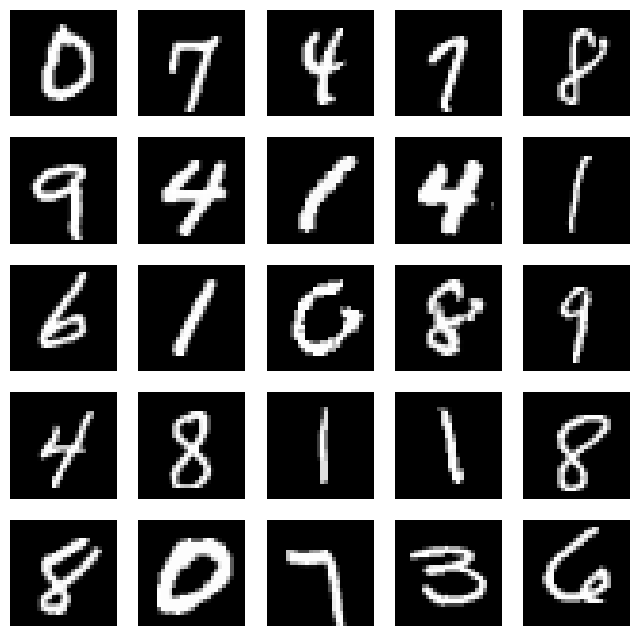

In [32]:
def show_mnist(xs, n=25):
  xs = xs[:n].detach().cpu()
  xs = ((xs + 1) / 2).clamp(0, 1)

  cols = min(n, 5)
  rows = (n + cols - 1) // cols
  fig, axes = plt.subplots(rows, cols, figsize=(1.6*cols, 1.6*rows))
  axes = fig.axes

  for i, axis in enumerate(axes):
    axis.axis('off')
    if i < len(xs):
      axis.imshow(xs[i, 0], cmap='gray')
  plt.show()

real_images, real_labels = next(iter(train_loader))
show_mnist(real_images, n=25)

A DCGAN-style generator for MNIST can be smaller than the earlier $64\times64$ RGB generator. The latent vector is first projected to a small $7\times7$ spatial grid with many channels. Two transposed convolution layers then upsample from $7\times7$ to $14\times14$ and finally to $28\times28$. This follows the same design principle as DCGAN: use learned convolutional upsampling rather than a fully connected layer for every output pixel. The discriminator reverses this process. It receives a $1\times28\times28$ image, applies strided convolutions, and returns one logit. The discriminator is still just a binary classifier, but now the classifier is convolutional because digit strokes are spatial patterns.


In [33]:
LATENT_DIM = 64

class MNISTGenerator(nn.Module):
  def __init__(self, latent_dim=LATENT_DIM):
    super().__init__()
    self.fc = nn.Linear(latent_dim, 128 * 7 * 7)
    self.net = nn.Sequential(
      nn.BatchNorm2d(128),
      nn.ReLU(True),
      nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
      nn.BatchNorm2d(64),
      nn.ReLU(True),
      nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
      nn.Tanh(),
    )

  def forward(self, z):
    h = self.fc(z).view(z.size(0), 128, 7, 7)
    return self.net(h)

In [34]:
class MNISTDiscriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Conv2d(1, 64, 4, 2, 1),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Conv2d(64, 128, 4, 2, 1),
      nn.BatchNorm2d(128),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Flatten(),
      nn.Linear(128 * 7 * 7, 1),
    )

  def forward(self, x):
    return self.net(x)

In [35]:
mnist_G = MNISTGenerator().to(DEVICE)
mnist_D = MNISTDiscriminator().to(DEVICE)

z = torch.randn(8, LATENT_DIM, device=DEVICE)
fake_digits = mnist_G(z)
fake_logits = mnist_D(fake_digits)

fake_digits.shape, fake_logits.shape

(torch.Size([8, 1, 28, 28]), torch.Size([8, 1]))

The shape check should return generated images of shape `(batch, 1, 28, 28)` and discriminator logits of shape `(batch, 1)`. Nothing about the adversarial objective has changed. Real MNIST images receive target $1$ during the discriminator update, fake MNIST images receive target $0$ during the discriminator update, and fake images receive target $1$ during the generator update.

The update functions below are the image version of the earlier one-dimensional update functions. The discriminator update detaches the generated images. The generator update does not detach them, because gradients must pass through the discriminator score and into the generator. This is the same concept, now applied to image tensors.


In [36]:
def mnist_discriminator_update(generator, discriminator, optimizer, real_images):
  real_images = real_images.to(DEVICE, non_blocking=True)
  batch_size = real_images.size(0)

  z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
  fake_images = generator(z).detach()

  real_logits = discriminator(real_images)
  fake_logits = discriminator(fake_images)
  loss = discriminator_loss(real_logits, fake_logits)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  return loss.item()

In [37]:
def mnist_generator_update(generator, discriminator, optimizer, batch_size):
  z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
  fake_images = generator(z)
  fake_logits = discriminator(fake_images)
  loss = generator_loss(fake_logits)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  return loss.item()

A short MNIST GAN training run is enough to demonstrate the mechanics, but it should not be expected to produce perfect digits. GANs are sensitive to the relative strength of the generator and discriminator, and MNIST still has multiple modes corresponding to different digit identities and writing styles. Longer training, larger models, and careful tuning improve the samples.

In [38]:
mnist_G = MNISTGenerator().to(DEVICE)
mnist_D = MNISTDiscriminator().to(DEVICE)

opt_g_mnist = torch.optim.AdamW(mnist_G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d_mnist = torch.optim.AdamW(mnist_D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [39]:
EPOCHS = 50
history = {'d_loss': [], 'g_loss': []}

for e in range(EPOCHS):
  for batch_idx, (real_images, _) in enumerate(train_loader):
    d_loss = mnist_discriminator_update(mnist_G, mnist_D, opt_d_mnist, real_images)
    g_loss = mnist_generator_update(mnist_G, mnist_D, opt_g_mnist, real_images.size(0))

    history['d_loss'].append(d_loss)
    history['g_loss'].append(g_loss)

  print(f'epoch={e+1} d_loss={d_loss:.3f} g_loss={g_loss:.3f}')

epoch=1 d_loss=0.037 g_loss=4.204
epoch=2 d_loss=0.538 g_loss=1.626
epoch=3 d_loss=0.022 g_loss=4.542
epoch=4 d_loss=0.012 g_loss=4.936
epoch=5 d_loss=0.168 g_loss=2.519
epoch=6 d_loss=0.015 g_loss=5.284
epoch=7 d_loss=0.007 g_loss=5.745
epoch=8 d_loss=0.069 g_loss=3.579
epoch=9 d_loss=0.017 g_loss=4.941
epoch=10 d_loss=0.138 g_loss=2.983
epoch=11 d_loss=0.021 g_loss=4.641
epoch=12 d_loss=0.013 g_loss=5.922
epoch=13 d_loss=0.009 g_loss=5.791
epoch=14 d_loss=0.624 g_loss=2.935
epoch=15 d_loss=0.038 g_loss=4.295
epoch=16 d_loss=0.014 g_loss=4.991
epoch=17 d_loss=0.009 g_loss=6.113
epoch=18 d_loss=0.027 g_loss=4.418
epoch=19 d_loss=0.009 g_loss=5.497
epoch=20 d_loss=0.013 g_loss=6.039
epoch=21 d_loss=0.006 g_loss=5.468
epoch=22 d_loss=0.005 g_loss=6.617
epoch=23 d_loss=0.090 g_loss=3.374
epoch=24 d_loss=0.022 g_loss=5.226
epoch=25 d_loss=0.014 g_loss=5.734
epoch=26 d_loss=0.009 g_loss=6.062
epoch=27 d_loss=0.018 g_loss=6.292
epoch=28 d_loss=0.007 g_loss=6.953
epoch=29 d_loss=0.044 g_loss=

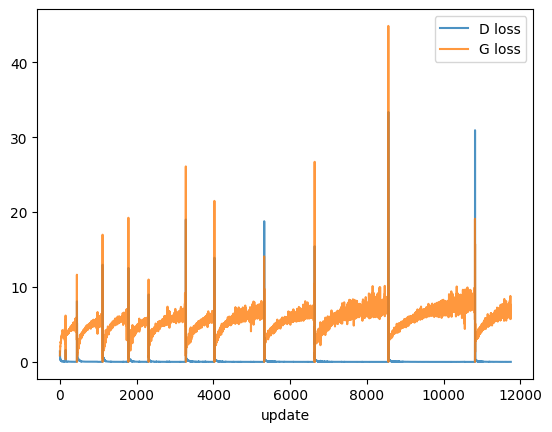

In [40]:
plt.plot(history['d_loss'], label='D loss', alpha=0.8)
plt.plot(history['g_loss'], label='G loss', alpha=0.8)
plt.xlabel('update')
plt.legend();

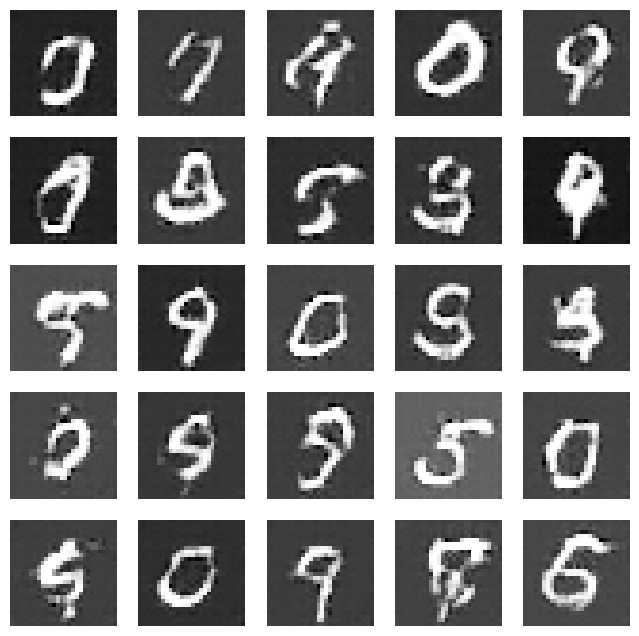

In [41]:
@torch.no_grad()
def sample_mnist_gan(generator, n=25):
  generator.eval()
  z = torch.randn(n, LATENT_DIM, device=DEVICE)
  samples = generator(z)
  generator.train()
  return samples

N = 25
mnist_samples = sample_mnist_gan(mnist_G, n=N)
show_mnist(mnist_samples, n=N)

The generated samples should become more digit-like as training proceeds, but the visual result depends on how long the model was trained. Early samples may show strokes, blobs, or partial digit shapes before they become recognizable. The generator is still trying to place probability mass where the training data has probability mass, but now that space is $28\times28$ dimensional.

<div class="admonition success">
  <p class="admonition-title">Exercise</p>
  <p style="margin: 1em 0;">
    Replace MNIST with CIFAR-10 and adapt the generator/discriminator to produce RGB images. Start with the DCGAN architecture above, normalize images to $[-1,1]$, and compare how training changes when the data distribution contains color, texture, background, and object-class variation. Another exercise is to train a conditional GAN either on MNIST (e.g. generate a certain digit) or CIFAR.
  </p>
</div>

## Fréchet Inception Distance

Visual inspection is necessary but subjective and costly. A common quantitative metric for image generators is the [Fréchet Inception Distance](https://en.wikipedia.org/wiki/Fr%C3%A9chet_inception_distance), usually abbreviated as **FID**. The usual FID procedure sends real and generated images through a pretrained [Inception](../../notebooks/05_cnn_architectures/#inception-googlenet) network, collects feature vectors, approximates the real and generated feature distributions as Gaussians, and then computes the [Fréchet distance](https://en.wikipedia.org/wiki/Fr%C3%A9chet_distance) between those two Gaussians. With real-image feature mean $\mu_r$ and covariance $\Sigma_r$, and generated-image feature mean $\mu_g$ and covariance $\Sigma_g$, FID is

$$
\mathrm{FID}
=
\|\mu_r-\mu_g\|_2^2
+
\operatorname{Tr}
\left(
\Sigma_r+\Sigma_g
-2(\Sigma_r\Sigma_g)^{1/2}
\right).
$$

The first term compares the centers of the two feature distributions. The [trace term](../../mathematics/02_linear_algebra/#trace-operator) compares their covariance structure, so it is sensitive to diversity as well as average appearance. A lower FID is better, and a perfect match in feature mean and covariance gives FID $0$. In practice, FID is not a proof of image quality. It depends on the feature network, the number of samples, and the domain.

The feature network is not part of the GAN. It is a measuring instrument. Its hidden representation gives a feature space where real and generated digits can be compared more meaningfully than raw pixels. For a serious experiment, this feature network should be trained and validated carefully, or replaced with a standard feature extractor appropriate for the image domain.

We will be using an external library which calculates FID, as the manual implementation is slightly heavy and will distract us from the main topic. The next helper functions collect features for real MNIST images and generated MNIST images. The generated features are collected in batches because FID is usually computed from many samples. Small sample counts make the estimate noisy, but they keep the notebook fast.

In [43]:
!pip install -q torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.6 MB/s eta 0:00:00


In [44]:
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)

def prepare_for_fid(x):
  x = ((x + 1) / 2).clamp(0, 1)
  if x.size(1) == 1:
    x = x.repeat(1, 3, 1, 1)
  return x

@torch.no_grad()
def update_fid_real(fid, loader, n=2048):
  total = 0

  for x, _ in loader:
    x = prepare_for_fid(x.to(DEVICE))
    fid.update(x, real=True)
    total += x.size(0)
    if total >= n:
      break

@torch.no_grad()
def update_fid_fake(fid, generator, n=2048, batch_size=128):
  generator.eval()
  total = 0

  while total < n:
    current = min(batch_size, n - total)
    z = torch.randn(current, LATENT_DIM, device=DEVICE)
    x = generator(z)
    x = prepare_for_fid(x)
    fid.update(x, real=False)
    total += current

  generator.train()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 503MB/s]


In [45]:
fid.reset()

update_fid_real(fid, train_loader, n=2048)
update_fid_fake(fid, mnist_G, n=2048)

mnist_fid = fid.compute()
mnist_fid

tensor(86.1059, device='cuda:0')

A lower value means that the generated images are closer to the real images in the feature space used by the metric. Since the feature extractor is based on natural-image Inception features, the value should be treated as a rough diagnostic rather than a definitive judgment of digit quality.

<div class="admonition success">
  <p class="admonition-title">Exercise</p>
  <p style="margin: 1em 0;">
    Implement FID manually. Collect feature vectors for real and generated images, compute their means and covariance matrices, and evaluate the formula described above. Compare your result with the `torchmetrics` implementation.
  </p>
</div>

FID considers both the average feature location and the spread of generated samples. If a generator creates only one kind of digit, the covariance term should reveal that the generated distribution is too narrow. This is why FID is more informative than looking at a single generated image, although visual inspection and nearest-neighbor checks are important.

## Label Smoothing and Noisy Labels

A small practical modification is **one-sided label smoothing**. Instead of training the discriminator with real labels equal to exactly $1$, real labels might be set to $0.9$. Fake labels are usually left at $0$. The goal is to reduce discriminator overconfidence, especially early in training.

<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
    Label smoothing should not be treated as a universal fix. If used carelessly, it can make the discriminator too weak or blur the distinction the generator needs to learn from. It is best understood as one stabilizing tool among many, not as a replacement for good architecture, reasonable learning rates, and careful sample inspection.
  </p>
</div>

In [46]:
def discriminator_loss_smooth(real_logits, fake_logits, real_value=0.9):
  real_targets = torch.full_like(real_logits, real_value)
  fake_targets = torch.zeros_like(fake_logits)
  real_loss = bce(real_logits, real_targets)
  fake_loss = bce(fake_logits, fake_targets)
  return real_loss + fake_loss

Another related idea is to add small noise to inputs during early discriminator training. If real and fake samples lie on very different regions of the input space, the discriminator may separate them too easily and provide poor gradients. Adding noise can smooth the classification problem at the beginning, then the noise level can be reduced over time.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    These tricks reveal a general lesson about GANs. The discriminator should be strong enough to identify meaningful differences, but not so strong that the generator receives no useful learning signal. Much of practical GAN training is about maintaining this balance.
    <br>
    The same warning applies to generator loss. A low generator loss can mean that generated samples fool the discriminator. It can also mean that the discriminator is weak. A high generator loss can mean that the generator is poor, or simply that the discriminator has temporarily become strong. GAN losses are diagnostic signals, not final evaluation metrics.
  </p>
</div>

<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
    A discriminator accuracy near 50% is not automatically good. It can mean that the generator has matched the data distribution, but it can also mean that the discriminator is poorly trained. Generated samples, diversity checks, and appropriate evaluation metrics should be considered together.
  </p>
</div>

## Common Failure Modes

GANs can generate sharp and convincing samples, but training them is delicate. There is even a dedicated repository called [GAN Hacks](https://github.com/soumith/ganhacks) with tips and tricks to train GAN models.

As noted, the most famous failure is **mode collapse**, where the generator produces a narrow set of outputs that exploit weaknesses in the discriminator. In a face generator, this could mean many outputs share nearly the same pose or identity. In the one-dimensional example, it appears as generated samples covering only one of the two peaks.

Another difficulty is **discriminator overpowering**. If the discriminator becomes too accurate too early, the generator may receive gradients that do not guide it toward the data distribution. The opposite imbalance is also bad: if the discriminator is too weak, it cannot provide useful feedback. GAN training is therefore a coupled optimization problem, not just two independent neural network trainings.

Evaluation is also difficult. Many GANs do not provide a tractable _likelihood_, so ordinary probability-based evaluation is unavailable. The FID calculation above gives one useful summary, but it is not a perfect replacement for inspecting sample quality, diversity, and possible memorization.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    When training a GAN, inspect generated samples throughout training. Loss values alone can be misleading because the generator and discriminator losses depend on each other. A model with attractive loss curves may still collapse, and a model with noisy losses may still produce useful samples.
  </p>
</div>

Several practical tricks are common in GAN training. _Label smoothing_ can prevent the discriminator from becoming overconfident. _Instance noise_ can make the discriminator's task smoother early in training. _Spectral normalization_ constrains discriminator layers and often stabilizes training. _Gradient penalties_ can encourage smoother critics. Architecture choices, normalization layers, learning rates, and the number of discriminator updates per generator update all affect the balance between the two networks.

## Conclusion

In this notebook, we discussed GANs. But GANs are only one of the many possible methods for generative deep learning. Not having a decreasing, likelihood-based loss function, and the problem of mode collapse gave rise to the emerging popularity of diffusion models. Before discussing the modern SOTA (as of 2026), however, we need to get acquainted with probability-heavy Variational Autoencoders...